# 02 — Exploratory Data Analysis (EDA)

This notebook explores the cleaned loan dataset to understand variable distributions, relationships, and patterns associated with loan default. The goal is to answer the research questions related to key predictors, borrower profiles, and risk patterns.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')  

In [17]:
# loading the cleaned dataset
df = pd.read_csv("C:/Users/user/Loan_default_predictor/data/clean/Loan_default_clean.csv")
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,1,1,Other,1,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,0,0,Other,1,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,1,1,Auto,0,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,0,0,Business,0,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,0,1,Auto,0,0


In [18]:
# Overview of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          4999 non-null   str    
 1   Age             4999 non-null   int64  
 2   Income          4999 non-null   int64  
 3   LoanAmount      4999 non-null   int64  
 4   CreditScore     4999 non-null   int64  
 5   MonthsEmployed  4999 non-null   int64  
 6   NumCreditLines  4999 non-null   int64  
 7   InterestRate    4999 non-null   float64
 8   LoanTerm        4999 non-null   int64  
 9   DTIRatio        4999 non-null   float64
 10  Education       4999 non-null   str    
 11  EmploymentType  4999 non-null   str    
 12  MaritalStatus   4999 non-null   str    
 13  HasMortgage     4999 non-null   int64  
 14  HasDependents   4999 non-null   int64  
 15  LoanPurpose     4999 non-null   str    
 16  HasCoSigner     4999 non-null   int64  
 17  Default         4999 non-null   int64  
dtyp

In [19]:
df.describe()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,HasDependents,HasCoSigner,Default
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.00000,4999.000000,4999.000000
mean,43.586117,82714.654331,128621.769154,575.599120,58.939588,2.494899,13.447069,36.266453,0.501984,0.495699,0.49970,0.501300,0.117223
std,14.920200,39177.543816,70265.433699,158.136138,34.473284,1.123401,6.624820,17.038789,0.229135,0.500032,0.50005,0.500048,0.321719
min,18.000000,15008.000000,5020.000000,300.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.00000,0.000000,0.000000
25%,31.000000,49097.000000,67764.500000,438.000000,28.000000,1.000000,7.665000,24.000000,0.310000,0.000000,0.00000,0.000000,0.000000
50%,43.000000,82363.000000,129042.000000,578.000000,59.000000,2.000000,13.630000,36.000000,0.510000,0.000000,0.00000,1.000000,0.000000
75%,56.000000,116685.500000,188907.000000,707.000000,88.000000,4.000000,19.195000,48.000000,0.700000,1.000000,1.00000,1.000000,0.000000
max,69.000000,149975.000000,249863.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000,1.00000,1.000000,1.000000


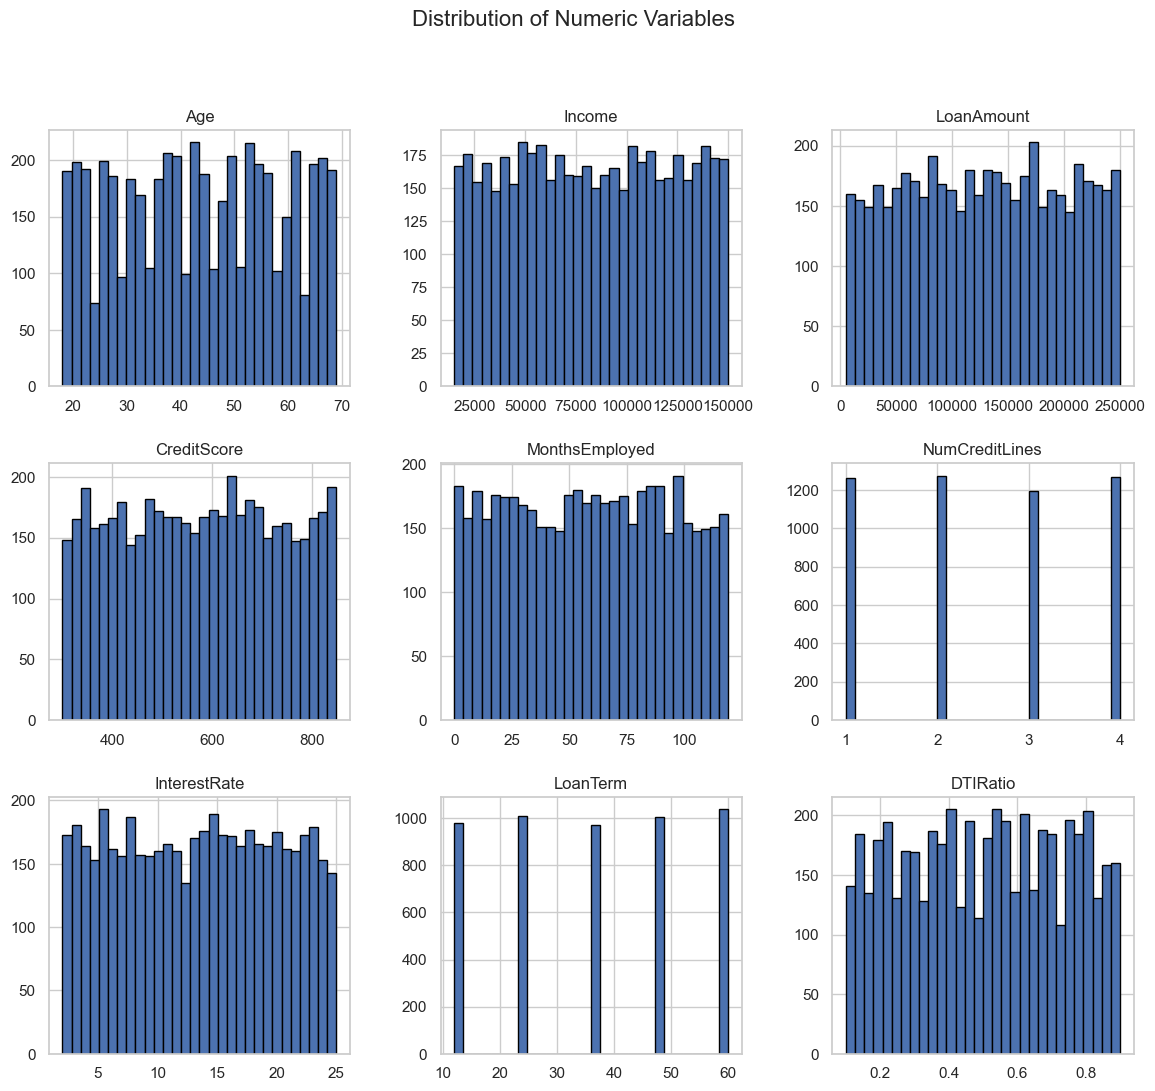

In [20]:
# Distribution of numeric variables
numeric_cols = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
                'NumCreditLines','InterestRate','LoanTerm','DTIRatio']

df[numeric_cols].hist(figsize=(14,12), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numeric Variables", fontsize=16)
plt.show()


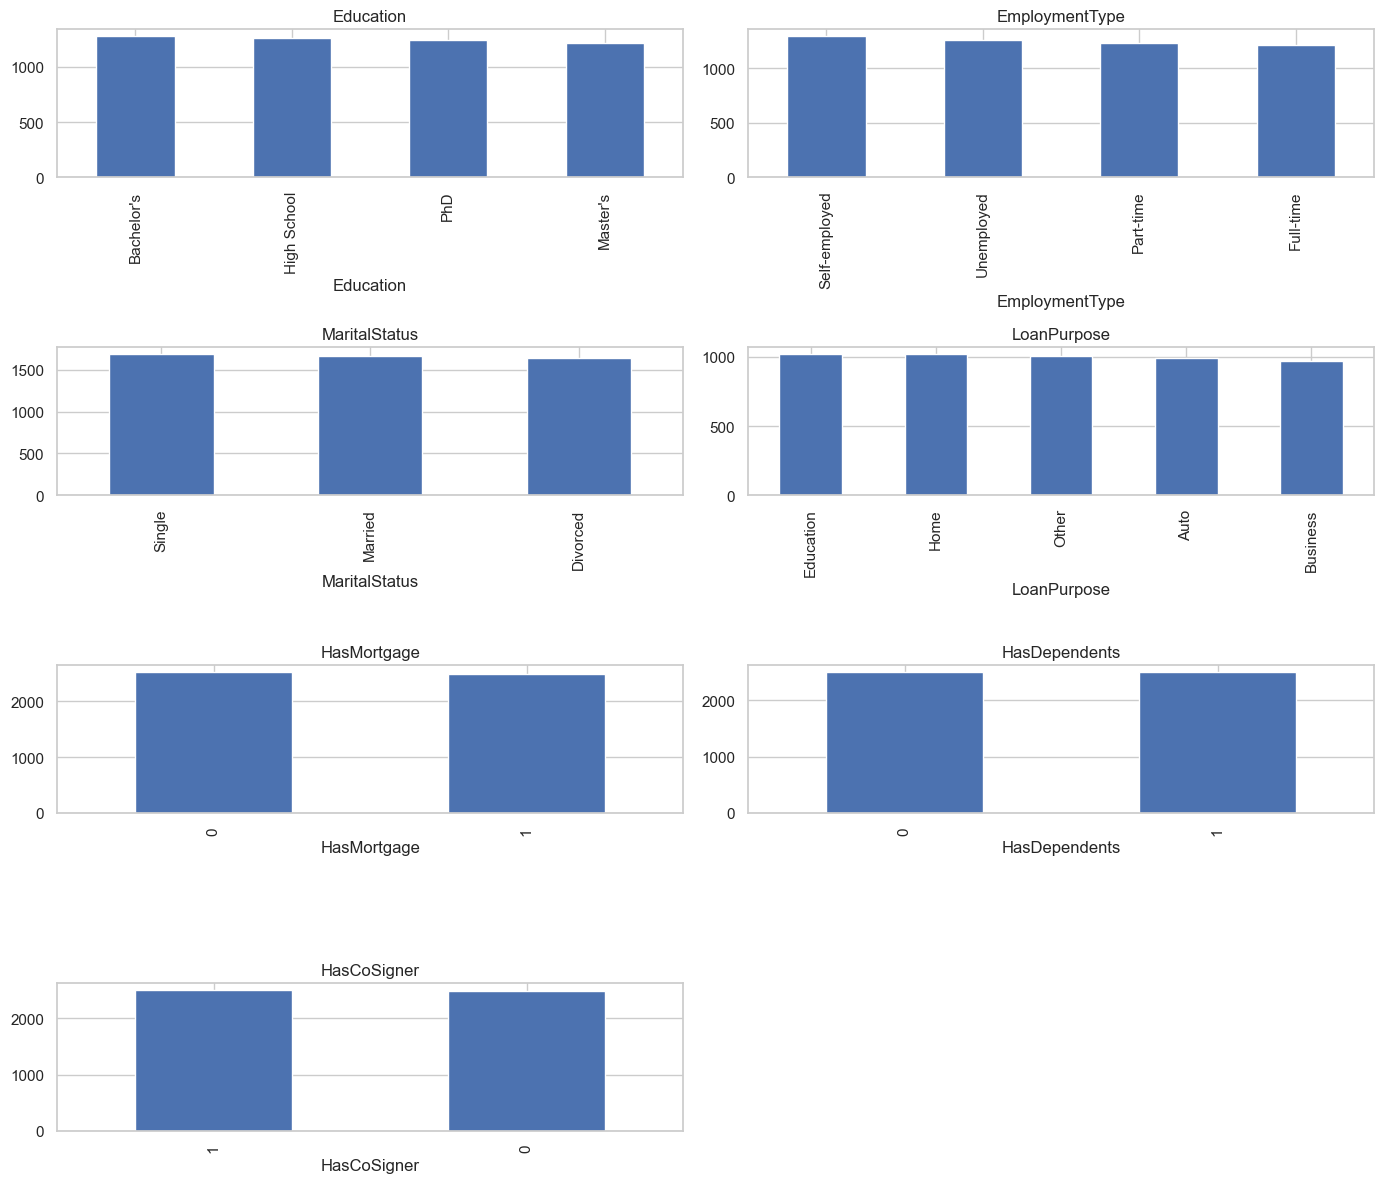

In [21]:
# Distribution of categorical variables
categorical_cols = ['Education','EmploymentType','MaritalStatus',
                    'LoanPurpose','HasMortgage','HasDependents','HasCoSigner']

plt.figure(figsize=(14,12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4,2,i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
plt.tight_layout()
plt.show()


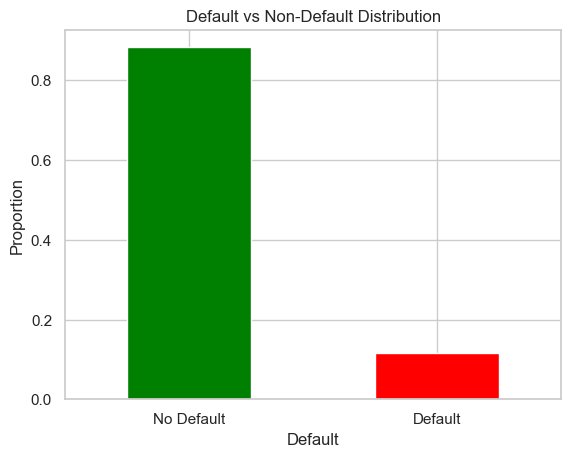

In [22]:
# Default rate overview
df['Default'].value_counts(normalize=True).plot(kind='bar', color=['green','red'])
plt.title("Default vs Non-Default Distribution")
plt.xticks([0,1], ['No Default','Default'], rotation=0)
plt.ylabel("Proportion")
plt.show()


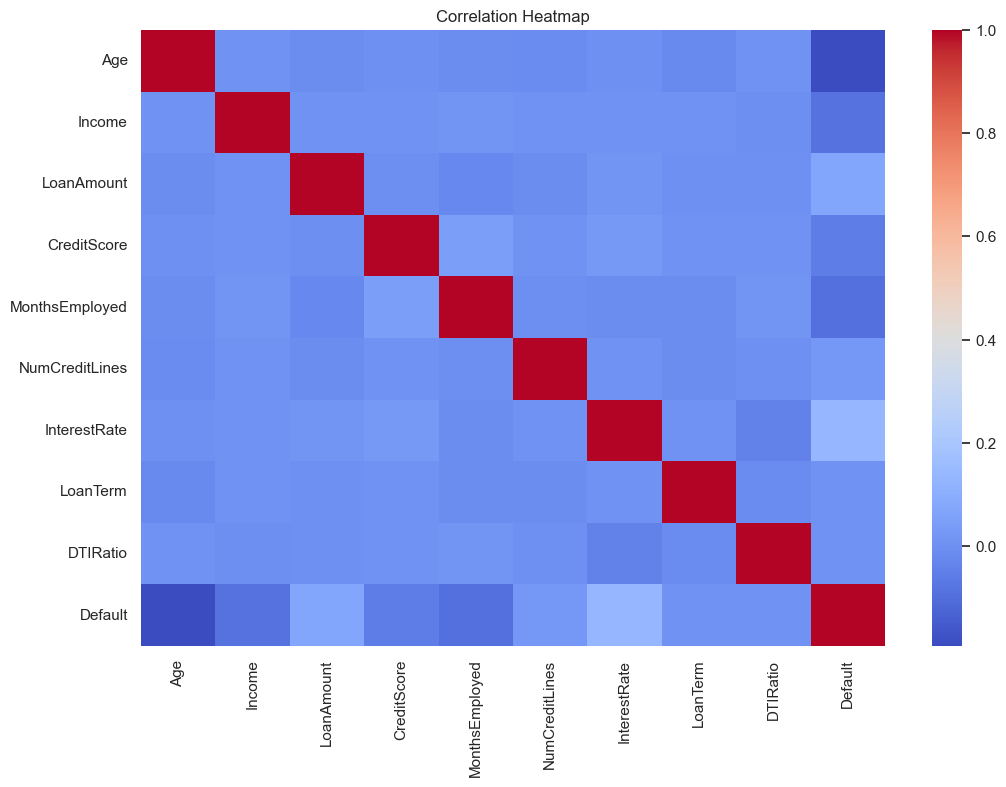

In [24]:
# Correlation heatmap(numeric variables)
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols + ['Default']].corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


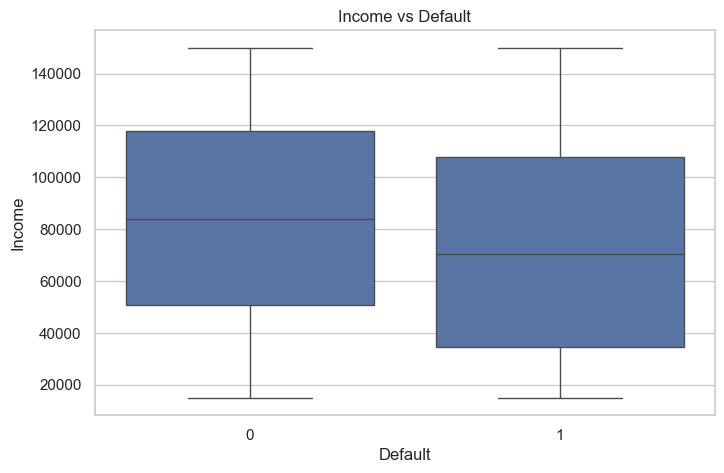

In [25]:
# Relationship Between Key Variables and Default
# Income vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='Income', data=df)
plt.title("Income vs Default")
plt.show()


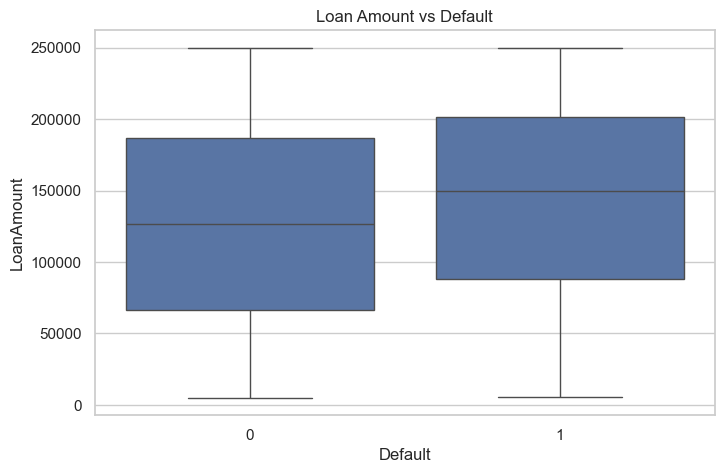

In [26]:
# Loan Amount vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='LoanAmount', data=df)
plt.title("Loan Amount vs Default")
plt.show()


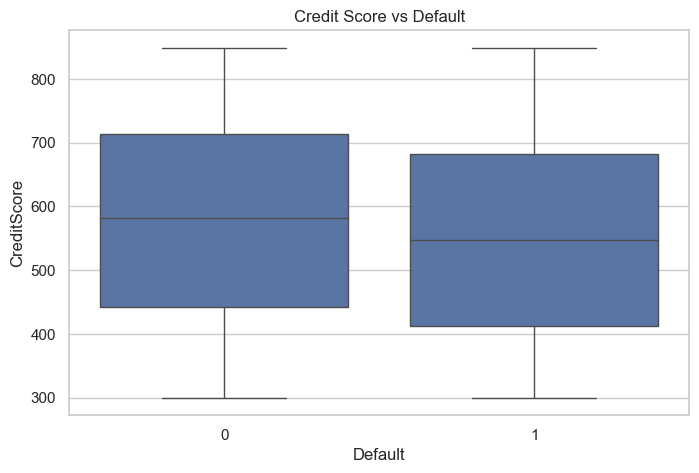

In [27]:
# Credit Score vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()


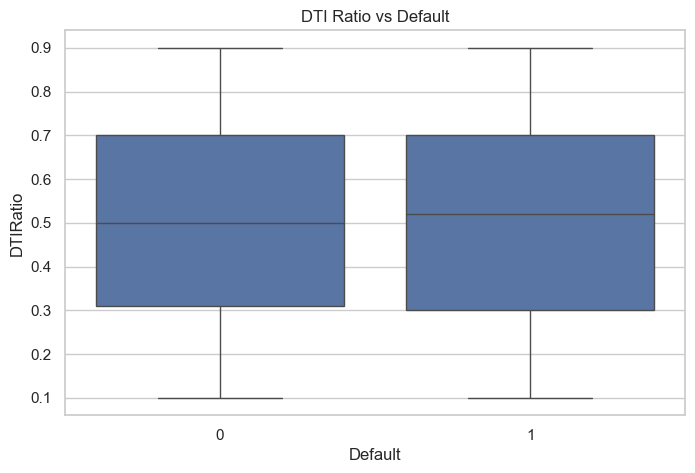

In [28]:
# DTI ratio vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='DTIRatio', data=df)
plt.title("DTI Ratio vs Default")
plt.show()


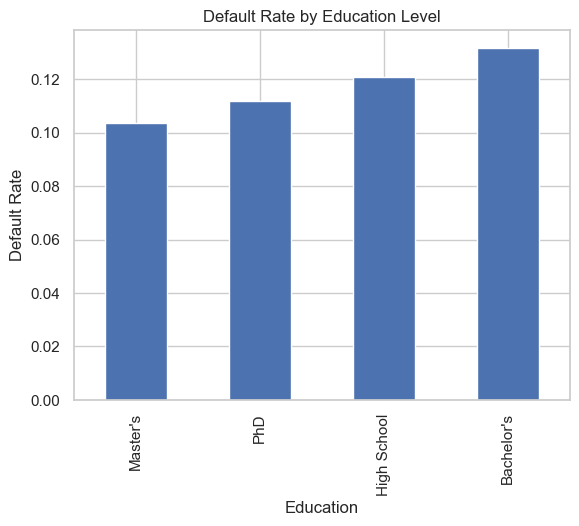

In [29]:
# Default rate by categorical variables
# Education

df.groupby('Education')['Default'].mean().sort_values().plot(kind='bar')
plt.title("Default Rate by Education Level")
plt.ylabel("Default Rate")
plt.show()


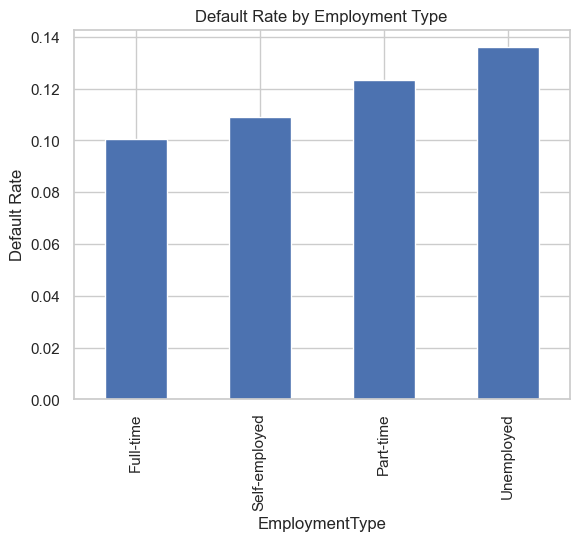

In [30]:
# Employment Type
df.groupby('EmploymentType')['Default'].mean().sort_values().plot(kind='bar')
plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")
plt.show()


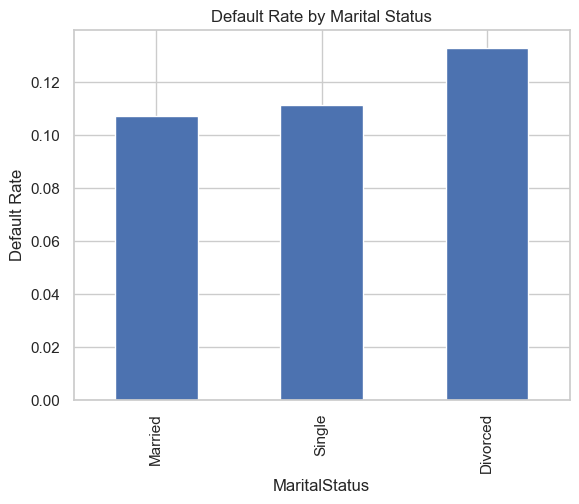

In [31]:
# Marital Status
df.groupby('MaritalStatus')['Default'].mean().sort_values().plot(kind='bar')
plt.title("Default Rate by Marital Status")
plt.ylabel("Default Rate")
plt.show()


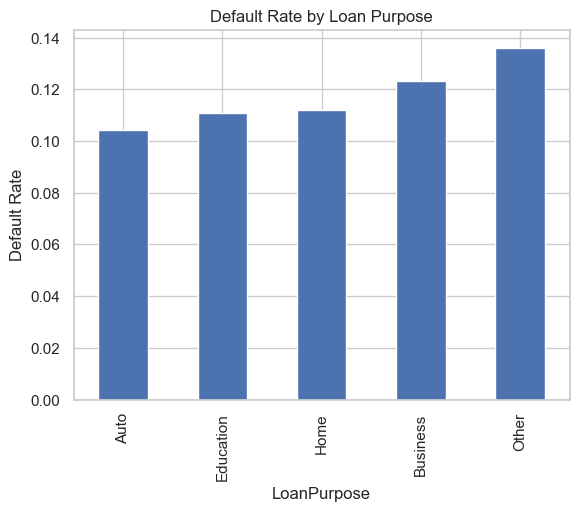

In [34]:
# Loan purpose
df.groupby('LoanPurpose')['Default'].mean().sort_values().plot(kind='bar')
plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")
plt.show()



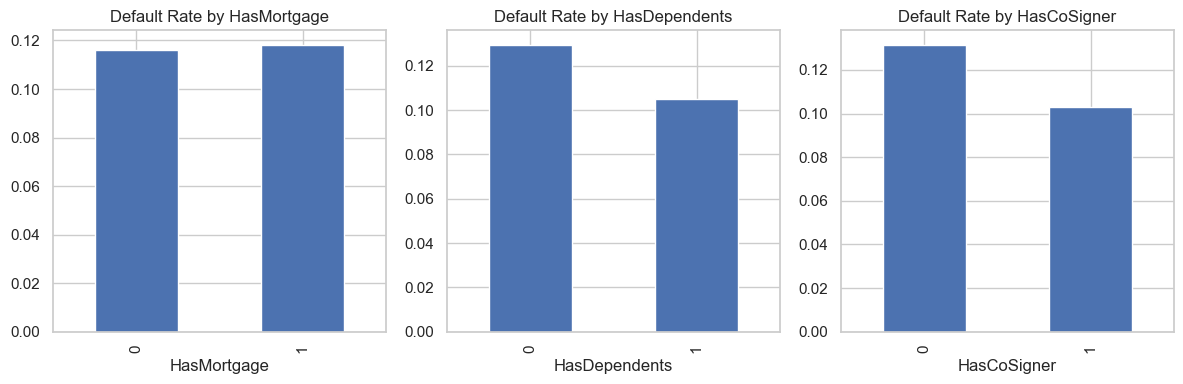

In [35]:
# Mortgage/Dependants/Co-signer
binary_cols = ['HasMortgage','HasDependents','HasCoSigner']

plt.figure(figsize=(12,4))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(1,3,i)
    df.groupby(col)['Default'].mean().plot(kind='bar')
    plt.title(f"Default Rate by {col}")
plt.tight_layout()
plt.show()


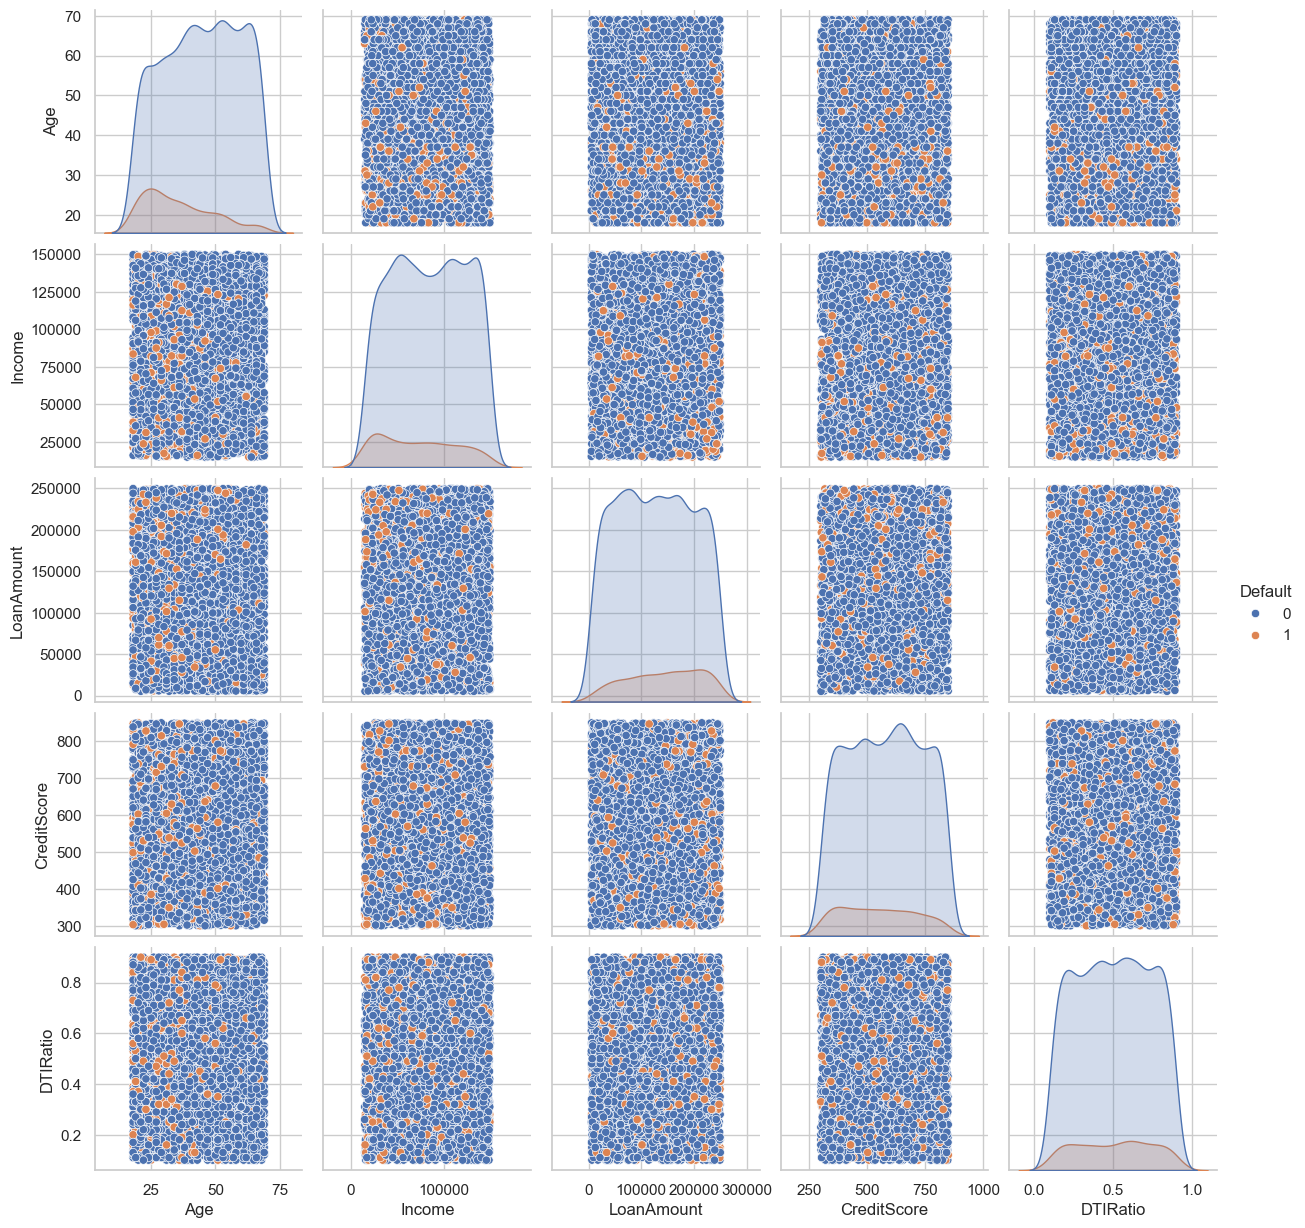

In [36]:
# Pairplot
sns.pairplot(df[['Age','Income','LoanAmount','CreditScore','DTIRatio','Default']], 
             hue='Default', diag_kind='kde')
plt.show()


# Key Insights from EDA

- Borrowers with **lower income**, **higher loan amounts**, and **higher DTI ratios** show higher default rates.
- **Credit score** is strongly negatively correlated with default.
- Employment type matters: unemployed and self-employed borrowers show higher risk.
- Loan purpose influences risk: business and auto loans show higher default rates.
- Borrowers with **no co-signer** or **no mortgage** tend to default more.
- Numeric variables show moderate correlations, suggesting non-linear relationships — useful for tree-based models.
